In [132]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
import torch
import torch.nn as nn

In [184]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
import re

class IPTransformer(BaseEstimator, TransformerMixin):
    """Splits IP strings into 4 numerical octets."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Convert '10.10.1.50' -> [10, 10, 1, 50]
        ips = X.iloc[:, 0].str.split('.', expand=True).astype(int)
        ips.columns = [f'ip_{i}' for i in range(4)]
        return ips

    def get_feature_names_out(self, input_features=None):
        return np.array([f'ip_{i}' for i in range(4)])

class DateTransformer(BaseEstimator, TransformerMixin):
    """Extracts behavioral features from timestamps."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        dt = pd.to_datetime(X.iloc[:, 0])
        return pd.DataFrame({
            'hour': dt.dt.hour,
            'day_of_week': dt.dt.dayofweek,
            'is_weekend': dt.dt.dayofweek.isin([5, 6]).astype(int)
        })
    def get_feature_names_out(self, input_features=None):
        return np.array(['hour', 'day_of_week', 'is_weekend'])
    
class ContentLengthTransformer(BaseEstimator, TransformerMixin):
    """Extract and standardize content length from string"""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        target_col = X['content_length']
        extracted = target_col.str.extract(r"Content-Length:\s*(\d+)", expand=False)
        return pd.DataFrame(extracted.astype(float).fillna(0.0))
    
    def get_feature_names_out(self, input_features=None):
        return np.array(['content_length_clean'])
    

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import math

class URLFeatureExtractor(BaseEstimator, TransformerMixin):
    """Extracts dense numerical features from URLs to avoid sparse matrices."""
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        urls = X.iloc[:, 0] if isinstance(X, pd.DataFrame) else X
        
        df = pd.DataFrame()
        df['url_length'] = urls.apply(len)
        df['num_digits'] = urls.apply(lambda x: sum(c.isdigit() for c in str(x)))
        df['num_special_chars'] = urls.apply(lambda x: sum(not c.isalnum() for c in str(x)))
        df['digit_ratio'] = df['num_digits'] / (df['url_length'] + 1e-5)
        
        # Look for specific SQLi / XSS characters or keywords
        df['has_sql_chars'] = urls.apply(lambda x: sum(str(x).count(c) for c in ["'", "\"", "=", "--", ";"]))
        df['has_script'] = urls.apply(lambda x: 1 if 'script' in str(x).lower() else 0)
        df['has_union'] = urls.apply(lambda x: 1 if 'union' in str(x).lower() else 0)
        df['has_select'] = urls.apply(lambda x: 1 if 'select' in str(x).lower() else 0)
        
        # Entropy
        def calc_entropy(string):
            p, lns = np.unique(list(str(string)), return_counts=True)
            return -np.sum((lns / np.sum(lns)) * np.log2(lns / np.sum(lns) + 1e-5))
        
        df['entropy'] = urls.apply(calc_entropy)
        return df
        
    def get_feature_names_out(self, input_features=None):
        return np.array(['url_length', 'num_digits', 'num_special_chars', 'digit_ratio', 
                         'has_sql_chars', 'has_script', 'has_union', 'has_select', 'entropy'])
    
class NaNLogger(BaseEstimator, TransformerMixin):
    def __init__(self, step_name=""):
        self.step_name = step_name

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if hasattr(X, "toarray"):
            temp_df = pd.DataFrame(X.toarray())
        else:
            temp_df = pd.DataFrame(X)
            
        nans = temp_df.isna().sum().sum()
        print(f"Total NaNs: {nans}")
        if nans > 0:
            print(f"Columns with NaNs:\n{temp_df.isna().sum()[temp_df.isna().sum() > 0]}")
        return X
        
def build_pipeline():
    content_pipeline = Pipeline([
        ('extractor', ContentLengthTransformer()),
        # ('nan_check', NaNLogger(step_name="After Extraction"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('time', DateTransformer(), ['timestamp']),
            # ('ip', IPTransformer(), ['client_ip']),
            ('url_text', URLFeatureExtractor(), ['url']),
            ('cat', OneHotEncoder(handle_unknown='ignore'), ['method', 'user']),
            ('num', content_pipeline, ['content_length'])
        ]
    )

    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        # ('scaler', StandardScaler(with_mean=False))
        ('detector', RandomForestClassifier(n_estimators=200,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1))
    ])
    return full_pipeline

In [163]:
train_df = pd.read_csv('csic-2010/train_dataset.csv')
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

test_df = pd.read_csv('csic-2010/test_dataset.csv')
X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

full_pipeline = build_pipeline()
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)
y_proba = full_pipeline.predict_proba(X_test)[:, 1]

/opt/anaconda3/envs/deepl/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/opt/anaconda3/envs/deepl/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


F1 Score: 0.6133369185264856
Precision Score: 0.9406185567010309
Recall Score: 0.455016955914622
[[7056  144]
 [2732 2281]]


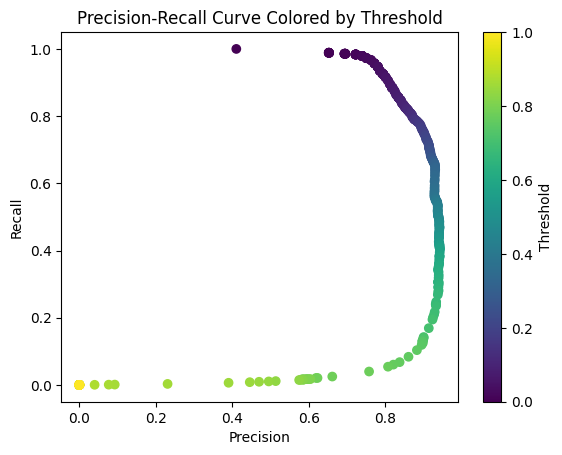

In [176]:
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve, confusion_matrix
def eval_random_forest(y_true, y_pred, y_proba):
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    confusion = confusion_matrix(y_true, y_pred)

    
    print(f"F1 Score: {f1}")
    print(f"Precision Score: {precision}")
    print(f"Recall Score: {recall}")
    print(confusion)

    p, r, thresholds = precision_recall_curve(y_true, y_proba)
    plt.figure()
    scatter = plt.scatter(x=p[:-1], y=r[:-1], c=thresholds)
    plt.xlabel("Precision")
    plt.ylabel("Recall")
    plt.title("Precision-Recall Curve Colored by Threshold")
    plt.colorbar(scatter, label="Threshold")
    plt.show()
    
eval_random_forest(y_test, y_pred, y_proba)

In [186]:
import joblib

train_df = pd.read_csv('csic-2010/train_dataset.csv')
X = train_df.drop('label', axis=1)
y = train_df['label']

full_pipeline = build_pipeline()
preprocessor = full_pipeline.named_steps['preprocessor']

X_processed_raw = preprocessor.fit_transform(X)
column_names = preprocessor.get_feature_names_out()

if hasattr(X_processed_raw, "toarray"):
    df_processed = pd.DataFrame(X_processed_raw.toarray(), columns=column_names)
else:
    df_processed = pd.DataFrame(X_processed_raw, columns=column_names)

df_processed['target_label'] = y.values
df_processed.to_csv('processed_train.csv', index=False)

In [136]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader

class LogDataset(Dataset):
    def __init__(self, csv_file_path):
        self.data = pd.read_csv(csv_file_path)
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        features = torch.tensor(self.data.iloc[idx, :-1].values, dtype=torch.float32)
        label = torch.tensor(self.data.iloc[idx, -1], dtype=torch.float32).unsqueeze(0)
        return features, label


In [248]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, in_features, bottleneck_dim=16, dropout_rate=0.2):
        super().__init__()
        
        # DENOISING: Randomly zero out parts of the input to force learning
        self.noise = nn.Dropout(p=dropout_rate)
        
        self.encoder = nn.Sequential(
            nn.Linear(in_features, in_features * 4),
            nn.BatchNorm1d(in_features * 4),
            nn.ReLU(),
            
            nn.Linear(in_features * 4, in_features),
            nn.BatchNorm1d(in_features),
            nn.ReLU(),
            
            nn.Linear(in_features, in_features // 2),
            nn.BatchNorm1d(in_features // 2),
            nn.ReLU(),
            
            nn.Linear(in_features // 2, bottleneck_dim),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, in_features // 2),
            nn.BatchNorm1d(in_features // 2),
            nn.ReLU(),
            
            nn.Linear(in_features // 2, in_features),
            nn.BatchNorm1d(in_features),
            nn.ReLU(),
            
            nn.Linear(in_features, in_features * 4),
            nn.BatchNorm1d(in_features * 4),
            nn.ReLU(),
            
            nn.Linear(in_features * 4, in_features)
        )
        
    def forward(self, x):
        noisy_x = self.noise(x)
        encoded = self.encoder(noisy_x)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
class AETrainer():
    def __init__(self, model, optim, loss_fn):
        self.optim = optim
        self.loss_fn = loss_fn
        self.model = model
    
    def train(self, batch_x):
        reconstructed = self.model(batch_x)
        
        # Loss is calculated against the input (ssl)
        loss = self.loss_fn(reconstructed, batch_x)
        
        self.optim.zero_grad()
        loss.backward()
        self.optim.step()
        return loss

def train_autoencoder(epochs, input_dim):
    # Assuming label 0 is "Normal" and 1 is "Anomaly"
    train_dataset = LogDataset('csic-2010/processed/dense/processed_train.csv')
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

    model = Autoencoder(in_features=input_dim)
    
    # Use MSE for reconstruction error
    loss_fn = nn.MSELoss() 
    optim = torch.optim.Adam(model.parameters(), lr=5e-4)
    trainer = AETrainer(model, optim, loss_fn)

    for epoch in range(epochs):
        print(f"Starting Epoch: {epoch}")
        for i, (x_batch, y_batch) in enumerate(train_loader):
            
            # FILTER: We only want to train on NORMAL traffic (label == 0)
            # Adjust the condition if your normal label is 1
            normal_mask = (y_batch == 0).squeeze()
            
            # Skip batch if there are no normal samples in it
            if not normal_mask.any():
                continue 
                
            x_normal = x_batch[normal_mask]
            
            loss = trainer.train(x_normal)
            
            if i % 25 == 0:
                print(f"\tStep {i}/{len(train_loader)}, Reconstruction Loss: {loss.item():.6f}")
                
    return model

ae_model = train_autoencoder(epochs=100, input_dim=66)

Starting Epoch: 0
	Step 0/96, Reconstruction Loss: 175.306427
	Step 25/96, Reconstruction Loss: 212.670822
	Step 50/96, Reconstruction Loss: 190.159882
	Step 75/96, Reconstruction Loss: 169.001358
Starting Epoch: 1
	Step 0/96, Reconstruction Loss: 158.640137
	Step 25/96, Reconstruction Loss: 188.124878
	Step 50/96, Reconstruction Loss: 130.986938
	Step 75/96, Reconstruction Loss: 129.836456
Starting Epoch: 2
	Step 0/96, Reconstruction Loss: 154.661377
	Step 25/96, Reconstruction Loss: 121.411415
	Step 50/96, Reconstruction Loss: 102.339760
	Step 75/96, Reconstruction Loss: 85.618774
Starting Epoch: 3
	Step 0/96, Reconstruction Loss: 105.333519
	Step 25/96, Reconstruction Loss: 89.766731
	Step 50/96, Reconstruction Loss: 71.074211
	Step 75/96, Reconstruction Loss: 69.918739
Starting Epoch: 4
	Step 0/96, Reconstruction Loss: 51.204296
	Step 25/96, Reconstruction Loss: 67.615128
	Step 50/96, Reconstruction Loss: 40.690723
	Step 75/96, Reconstruction Loss: 65.351799
Starting Epoch: 5
	Step

Dynamic Threshold set to: 4.381621
F1 Score: 0.6637287525856642
Precision Score: 0.6043236161152964
Recall Score: 0.7360861759425493
[[4784 2416]
 [1323 3690]]


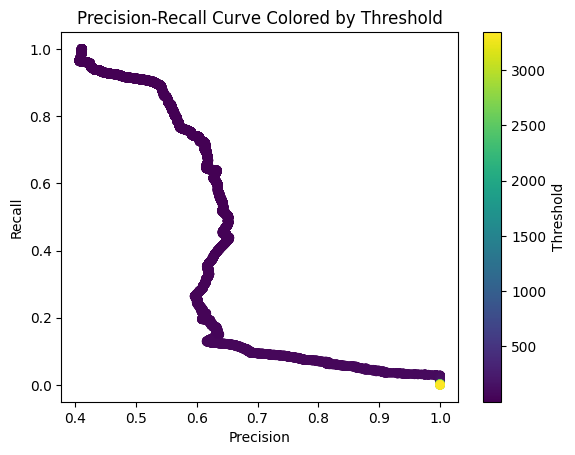

In [ ]:
@torch.no_grad()
def infer_anomalies(model, test_loader, threshold=None):
    model.eval()
    
    all_errors = []
    all_labels = []
    
    # Use reduction='none' so we get the error for each row
    loss_fn = nn.MSELoss(reduction='none')
    
    for x_batch, y_batch in test_loader:
        reconstructed = model(x_batch)
        row_errors = loss_fn(reconstructed, x_batch).mean(dim=1)
        all_errors.append(row_errors.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy().ravel())
        
    errors = np.concatenate(all_errors)
    labels = np.concatenate(all_labels)
    
    # in production: calculate threshold on a clean validation set of only normal data.
    if threshold is None:
        threshold = np.percentile(errors, 50)
        print(f"Dynamic Threshold set to: {threshold:.6f}")
        
    predictions = (errors > threshold).astype(int)
    
    return predictions, labels, errors


predictions, labels, errors = infer_anomalies(ae_model, test_loader)
eval_random_forest(labels, predictions, errors)